In [ ]:
import scanpy as sc
#raw data
adata=scv.datasets.gastrulation_erythroid()

In [2]:
import scvelo as scv
#adata的默认矩阵是spliced
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000, log=True, subset_highly_variable =True)

Filtered out 47456 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


In [3]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

<AxesSubplot:title={'center':'sample'}, xlabel='UMAP1', ylabel='UMAP2'>

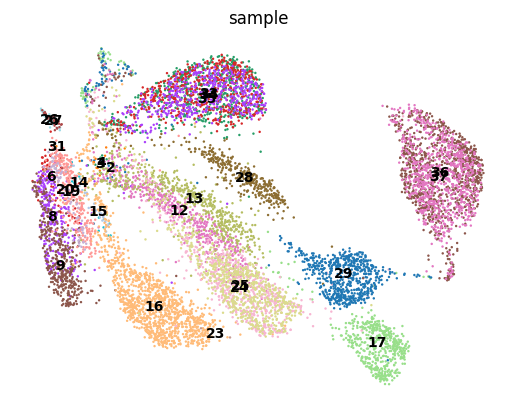

In [9]:
sc.pl.umap(adata,color="sample", palette=sc.pl.palettes.default_20, legend_loc='on data', show=False, frameon=False)

<AxesSubplot:title={'center':'celltype'}, xlabel='UMAP1', ylabel='UMAP2'>

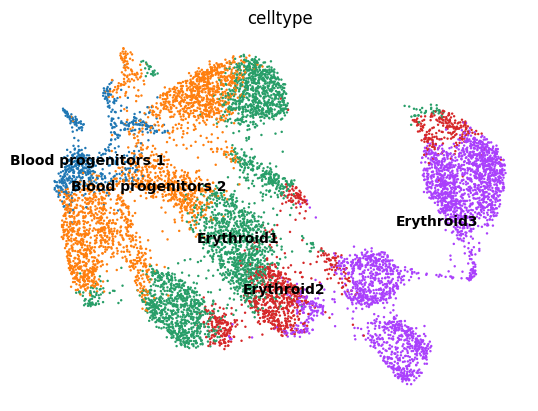

In [8]:
sc.pl.umap(adata,color="celltype", palette=sc.pl.palettes.default_20, legend_loc='on data', show=False, frameon=False)

In [ ]:
import scvelo as scv
import numpy as np
import random
import torch

from AlignVelo.train import train, Constants
from AlignVelo._utils import update_dict
from AlignVelo.data import preprocess_data

SEED=123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)
random.seed(SEED)
adata=scv.datasets.gastrulation_erythroid()

# optional:filter out batches with less than 5 cells
import pandas as pd
batch_counts = pd.value_counts(adata.obs['sample'])
valid_batches = batch_counts[batch_counts >= 5].index
adata = adata[adata.obs['sample'].isin(valid_batches)].copy()

adata = preprocess_data(adata, batch_key="sample")

configs = {
    "name": "AlignVelo", # name of the experiment
    "data_loader": {
        "args": {"unspliced_layer": "Mu", "spliced_layer": "Ms"}},
    "arch": {
        "args": {
        "n_hidden": 256,
        "n_latent": 20,  
        "log_variational": False,
        "pred_unspliced": False,
        "batch_norm": "none",
        "layer_norm": "none",
        "kl_weight_z": 0.1,
        "mse_weight": 1,
        "lambda_": 0.2, 
        "epsilon":0.5,
        "ot_iteration": {'outer':10,'inner':5},
        "loss1_scale": 1.,
        "loss2_scale": 1.,
        "dropout_rate": 0.1,
        "scale1":1.,
        "scale2":1.,         
        },
    },
    "data_loader": {
            "type": "VeloDataLoader",
            "args": {
                "unspliced_layer": "Mu",
                "spliced_layer": "Ms",
                "batch_size": 1024,
                "shuffle": True,
                "validation_split": 0.1,
                "num_workers": 10,
                "velocity_genes": False,
                "use_scaled_u": False,
            },},
    "optimizer": {
        "args": {"lr": 1e-3, "weight_decay": 1e-4, "amsgrad": True, "eps":1e-8},
    },
    "parameter_lr": {"lr_decoder":3e-3,"lr_velo":0.01},
    "trainer": {"loss1_epochs": 10, "loss2_epochs": 40, "loss3_epochs":50}
    }
configs = update_dict(Constants.default_configs, configs)
trainer = train(adata, "sample", configs)
    
adata.write("./ourmethod_results_mid.h5ad")

In [1]:
import scanpy as sc
import scvelo as scv
adata=sc.read_h5ad("./ourmethod_results_mid.h5ad")

In [3]:
scv.pp.neighbors(adata, use_rep='z')  # 使用潜在空间 'z' 计算邻居
sc.tl.umap(adata)  # 计算 UMAP

computing neighbors
    finished (0:00:18) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


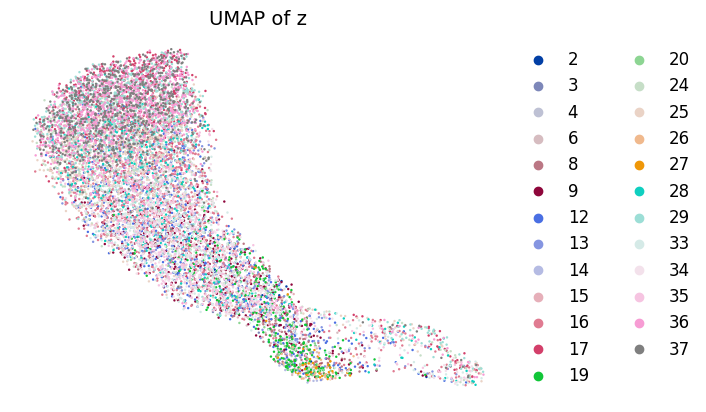

In [ ]:
scv.pp.neighbors(adata, use_rep='z')  # 使用潜在空间 'z' 计算邻居
sc.tl.umap(adata)  # 计算 UMAP

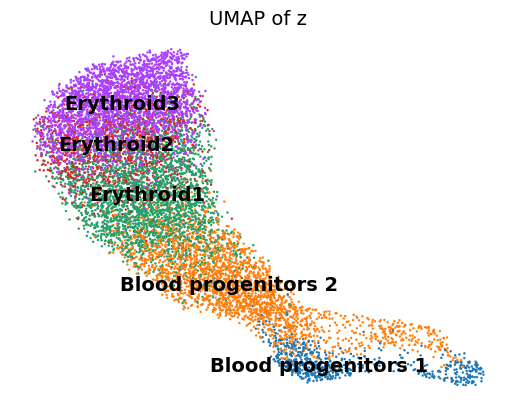

In [5]:
sc.pl.umap(adata, color='celltype' , title="UMAP of z", palette=sc.pl.palettes.default_20, legend_loc='on data', show=False, frameon=False)
plt.savefig('figures/AlignVelo_celltype_umap.png', dpi=300, bbox_inches='tight')

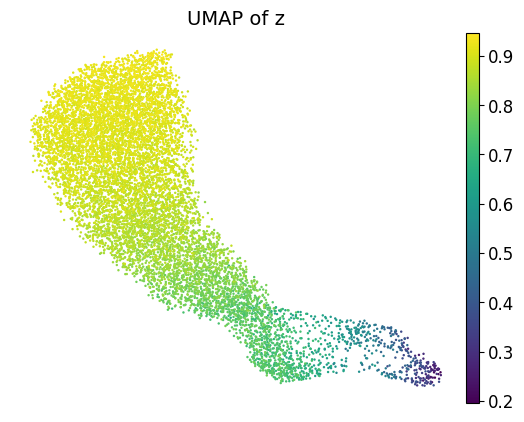

In [13]:
sc.pl.umap(adata, color='pseudotime', title="UMAP of z", palette=sc.pl.palettes.default_20, legend_loc='on data', show=False, frameon=False)
plt.savefig('figures/AlignVelo_pseudotime.pdf', dpi=300, bbox_inches='tight')

In [ ]:
#sc.pl.umap(adata, color='stage' , palette=sc.pl.palettes.default_20, title="UMAP of z", legend_loc='on data', show=False, frameon=False)

computing velocity graph (using 10/64 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file figures/AlignVelo_velocity_umap.pdf


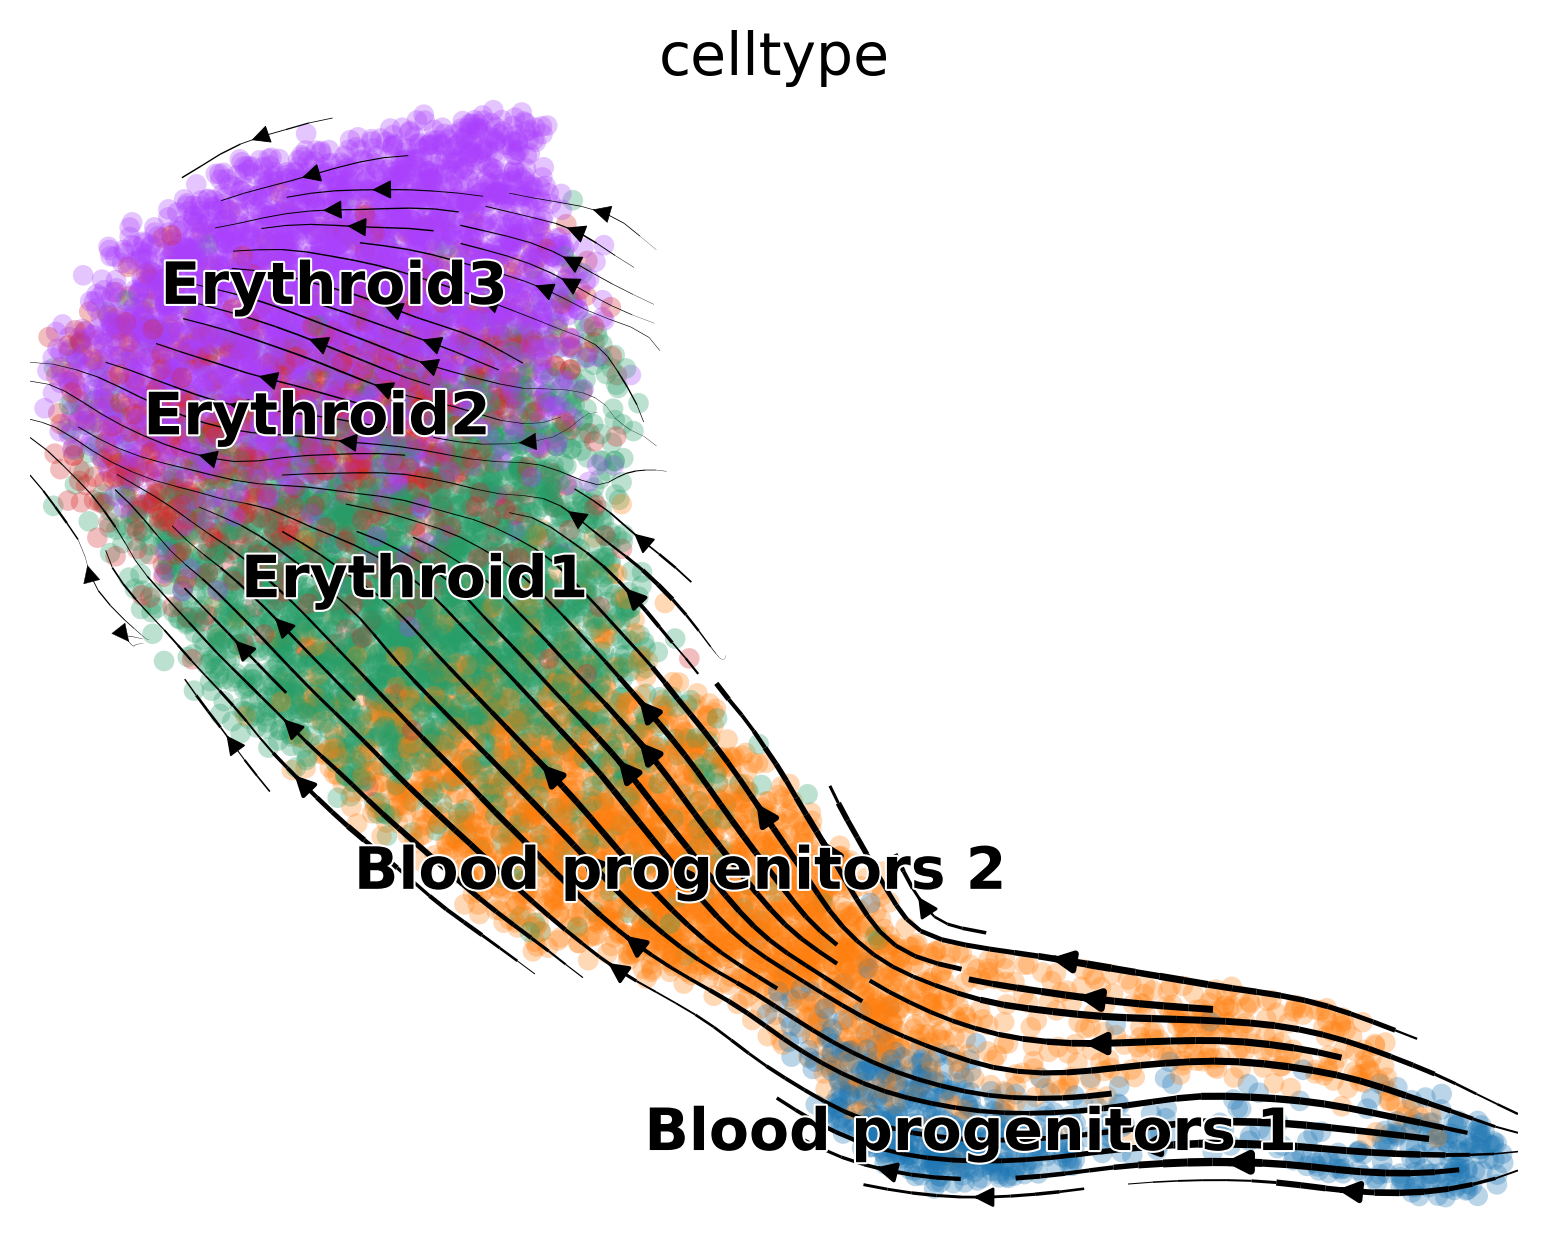

In [6]:
import scvelo as scv
scv.tl.velocity_graph(adata,n_jobs=10, vkey='velocity', xkey="correct_Ms")
scv.pl.velocity_embedding_stream(adata, basis='umap',color="celltype",dpi=300,save='figures/AlignVelo_velocity_umap.pdf')